This is the exercise on hypothesis testing, it will be done in parts.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

Part a:
There's a defined signal and background distribution $3(1-x^{2})$ and $3x^{2}$. x is a r.v between 0 to 1.

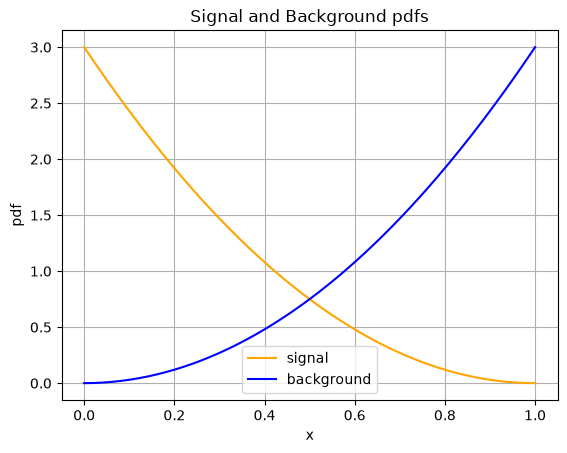

In [3]:

def sig(x):
    return 3*(1-x)**2

def back(x):
    return 3*x**2

x=np.linspace(0,1,200)

plt.figure()
plt.title("Signal and Background pdfs")
plt.xlabel("x")
plt.ylabel("pdf")
plt.plot(x,sig(x),label='signal',c='orange')
plt.plot(x,back(x),label='background',c='blue')
plt.legend(loc='best')
plt.grid()
plt.show()

To find the probability of rejecting the background hypothesis even though it is correct we have to integrate the probability distribution function upto a certain value known as the crital value/region. We use a module called quad for integration. The probability of such false negative is called significance level.

In [4]:
from scipy.integrate import quad

result_bag, error_bag = quad(back, 0, 1)
result_sig, error_sig = quad(sig, 0, 1)


print(result_bag)
print(result_sig)
print(error_bag)
print(error_sig)

1.0
1.0
1.1102230246251565e-14
1.1102230246251565e-14


Now we try to find the value of $x_{cut}$ which defines the critical region.

In [5]:
def integrate_pdf(pdf, a, b):
    result, error = quad(pdf, a, b)
    return result

alpha = 0.05

for i in x:
    a=integrate_pdf(back, 0, i)
    if a<=alpha:
        continue
    else:
        print("The value of x for which the integral of background pdf is greater than alpha is: ", i)
        #print("The value of x for which the integral of background pdf is greater than alpha is: ", a)
        x_cut=i
        break




The value of x for which the integral of background pdf is greater than alpha is:  0.37185929648241206


part 1b:

Now we are looking for the probability of correctly identifying a signal and rejecting the background hypothesis i.e. we are trying to identfy the power of the test of the background hypothesis with respect to the signal
alternative or equivalently the signal efficiency.

In [6]:
b=integrate_pdf(sig, 0, x_cut)
print("The probability of the observation being a signal is:", b)

The probability of the observation being a signal is: 0.7521603370505211


part 1c:

Suppose that the expected number of background events is $b_{tot} = 100$ and for a given signal model one expects $s_{tot} = 10$ signal events. Find the expected numbers of events s and b of signal and background events that will satisfy $x < x_{cut}$ using the value of $x_{cut} = 0.1$.


In [7]:
x_cut=0.1
b_tot=100
s_tot=10
s=s_tot*integrate_pdf(sig, 0, x_cut)
b=b_tot*integrate_pdf(back, 0, x_cut)

print("Expected number of signal events: ", s)
print("Expected number of background events: ", b)

Expected number of signal events:  2.710000000000001
Expected number of background events:  0.10000000000000002


part 1d:
Assuming the numbers from 1(c), the prior probabilities for an event to be signal or background are $\pi_{s}=0.09$ and $\pi_{b}=0.91$, Using Bayes’ theorem with these values, we have to find the probability for an event to be signal given that it has $x < x_{cut}$ (the signal purity of the selected sample).

In [8]:
back_prior=b_tot/(b_tot+s_tot)
sig_prior=s_tot/(b_tot+s_tot)

print("Prior probability of the observation being a signal: ", sig_prior)
print("Prior probability of the observation being a background: ", back_prior)

Prob_back=integrate_pdf(back, 0, 0.1)
Prob_sig=integrate_pdf(sig, 0, 0.1)

print("The probability of the observation being a background is:", Prob_back)
print("The probability of the observation being a signal is:", Prob_sig)

p_tot=Prob_sig*sig_prior+Prob_back*back_prior
print("The total probability of the observation is: ", p_tot)

p_final_sig=(Prob_sig*sig_prior)/p_tot
p_final_back=(Prob_back*back_prior)/p_tot   
print("The final probability of the observation being a signal is: ", p_final_sig)
print("The final probability of the observation being a background is: ", p_final_back)

Prior probability of the observation being a signal:  0.09090909090909091
Prior probability of the observation being a background:  0.9090909090909091
The probability of the observation being a background is: 0.0010000000000000002
The probability of the observation being a signal is: 0.2710000000000001
The total probability of the observation is:  0.025545454545454552
The final probability of the observation being a signal is:  0.9644128113879004
The final probability of the observation being a background is:  0.03558718861209964


Suppose for a certain xcut one has b = 0.5 and we find there $n_{obs} = 3$ events in the search region $x < x_{cut}$ . We want to test the hypothesis that s = 0 (the background-only hypothesis or “b”), against the alternative that signal is present with $s\neq 0 $ (the “s + b” hypothesis).

The actual number of events n found in the experiment with x < xcut can be modeled as following a Poisson distribution with a mean value of s + b. The p-value of the background-only hypothesis is the probability, assuming s = 0, to find $n ≥ n_{obs}$ :

$p = P(n \ge n_{\text{obs}} \mid s = 0, b) = \sum_{n=n_{\text{obs}}}^{\infty} \frac{b^n}{n!} e^{-b} = 1 - \sum_{n=0}^{n_{\text{obs}}-1} \frac{b^n}{n!} e^{-b} .$

We have to find the p-value using the values given above and from this we have to find the significance with which one can reject the s = 0 hypothesis, defined as:$\newline$
$  Z = \phi^{-1} (1 − p) $,

where $\phi$ is the standard cumulative Gaussian distribution and $\phi^{-1}$ is its inverse (the standard
Gaussian quantile).

In [9]:
import math
back_exp=0.5
back_obs=3
#s=0 is the Null hyposthesis and s>0 is the alternative hypothesis

def pois(s,b,n):
    return (np.exp(-(s+b))*(s+b)**n)/math.factorial(n)
tot=sum(pois(0,back_exp,n) for n in range(0,back_obs))
print("The p value of the background only hypothesis is:",1-tot)
print("The significance value:",sp.stats.norm.isf(1-tot))


The p value of the background only hypothesis is: 0.014387677966970713
The significance value: 2.186550477435837


part 1f:

The expected (median) significance assuming the s+b hypothesis of the test of the s = 0 hypothesis is a measure of sensitivity and this is what one tries to maximize when designing an experiment. It can be approximated with a number of different formulas. For s ≪ b one
can use $med[Z_{b} |s + b]=s/(\sqrt b)$. If s ≪ b does not hold, a better approximation is:

$med[Z_{b} |s + b] =\sqrt(2((s+b)ln(1+\frac{s}{b})-s)) $.

We have to find the median significance for $x_{cut} = 0.1$.

In [10]:
term1=s+b
term2=np.log(1+s/b)

significance=np.sqrt(2*((term1*term2)-s))

print("The expected significance value is:", significance)

The expected significance value is: 3.650619812994654


Now we try to find the value of $x_cut$ that maximizes the significance.

In [11]:

def sig(x):
    return 3*(1-x)**2

def back(x):
    return 3*x**2

def integrate_pdf(pdf, a, b):
    result, error = quad(pdf, a, b)
    return result

def Signif(s,b):
    term1=s+b
    term2=np.log(1+s/b)

    return np.sqrt(2*((term1*term2)-s))

x=np.linspace(0.001,1,1000)
s_tot=10
#s=s_tot*integrate_pdf(sig, 0, 1)

t=[]

#Finding the argument corresponding to the maximum value of significance.
for i in x:
    b_tot=100
    s_tot=10
    s=s_tot*integrate_pdf(sig, 0, i)
    b=b_tot*integrate_pdf(back, 0, i)
    #t=Signif(s,b)
    t.append(Signif(s,b))
    #print(Signif(s,b))

k=np.argmax(t)
#The value of x at that argument is our desired x_cut.
print("The value of x_cut for which the mean significance level is maximum is:",x[k])

    

    

The value of x_cut for which the mean significance level is maximum is: 0.127


part 1g:

Now suppose that for each event we do not simply count the events having x in a certain region but we design a test that exploits each measured value in the entire range 0 ≤ x ≤ 1.Thus there is no cut on x and in here we use s = 10 and b = 100 to refer to the total expected
numbers of signal and background events. The data consist of the number n of events, which follows a Poisson distribution with mean of s + b, and the n values x1 , . . . , xn .The Poisson probability to find n events can be written in terms of a strength parameter
µ as:

$P(n|\mu)=\frac{(\mu s+b)^{n}}{n!}exp(-(\mu s+b))$ where $\mu = 0$ corresponds to the background-only hypothesis and $\mu = 1$ adds to this the contribution from the signal. The joint distribution for
$\mathbf{x} = (x_1,\ldots,x_n)$ given $n$ is

\begin{equation*}
f(\mathbf{x}|n,\mu)=\prod_{i=1}^{n}\left[\frac{\mu s}{\mu s+b}f(x_i|s)+\frac{b}{\mu s+b}f(x_i|b)\right].
\end{equation*}

and the full likelihood is therefore

\begin{equation*}
L(\mu) = P(n,\mathbf{x}|\mu)= P(n|\mu)f(\mathbf{x}|n,\mu)
\end{equation*}

\begin{equation*}
= \frac{(\mu s+b)^n}{n!}e^{-(\mu s+b)}\prod_{i=1}^{n}\left[\frac{\mu s}{\mu s+b}f(x_i|s)+\frac{b}{\mu s+b}f(x_i|b)\right].
\end{equation*}

We can define a statistic $q$ to test the background-only hypothesis as:
\begin{equation*}
q = -2\sum_{i=1}^{n}\ln\left[1+\frac{s}{b}\frac{f(x_i|s)}{f(x_i|b)}\right]= -2\ln\frac{L(1)}{L(0)}+C,
\end{equation*}

where $C$ is a constant that can be dropped (the factor of $-2$ is conventional and could be omitted). This is a monotonic function of the likelihood ratio $L(1)/L(0)$ and thus according to the Neyman--Pearson lemma gives a test of $\mu=0$ with the highest possible sensitivity (highest power with respect to the alternative of $\mu=1$).

We are going to make a program that will produce histograms of $q$ under the $b$ and $s+b$ hypotheses, corresponding to the distributions
$f(q|\mu)$ for $\mu=0$ and $\mu=1$, respectively. The program also finds the median $q$ for the $s+b$ hypothesis, $\operatorname{med}[q|s+b]$.

We will also find the median $p$-value of the $b$-only hypothesis for the data generated under assumption of the $s+b$ hypothesis. That is, we first find the fraction of experiments simulated according to $b$-only that have $q < \operatorname{med}[q|s+b]$. From this, we find the $p$-value of the background-only hypothesis and the corresponding median significance $\operatorname{med}[Z_b|s+b]$ (the sensitivity). Finally we will compare the obtained results with part f.

First we define the signal background functions, the counts we got and the test staistic defined using Neymann Pearson lemma.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import scipy.stats as stats


def sig(x):
    return 3*(1-x)**2

def back(x):
    return 3*x**2

s_total=5
b_total=100

def q(x):
    return -2.*np.log(1. + (s_total/b_total)*sig(x)/back(x))



Now its time to generate the data for our experiment. We here employ as selection rejection type monte-carlo method to generate the signal+background data. Also note that we have just inverted the pdf to get the counts on signal+background as well as background only

In [41]:
 # Generate data under b and s+b hypotheses
qb = []
qsb = []
numExp = 100000
ps = s_total/(s_total+b_total)
np.random.seed(seed=1234567)        # fix random seed
for i in range(numExp):
    n = np.random.poisson(b_total)       # first b only
    r = np.random.uniform(0., 1., n)
    xb = r**(1./3.)
    qb.append(np.sum(q(xb)))
    n = np.random.poisson(s_total+b_total) # then s+b
    r1 = np.random.uniform(0., 1., n)
    r2 = np.random.uniform(0., 1., n)
    xsb = [1. - r1[j]**(1./3.) if r2[j]<ps else r1[j]**(1./3.) for j in range(n)]
    xsb = np.array(xsb)
    qsb.append(np.sum(q(xsb)))
    if len(qsb)%(numExp/100) == 0:
            print(".", end="", flush=True)
print("\n")
qb = np.array(qb)
qsb = np.array(qsb)

....................................................................................................



This is just a conversion block. Pickle converts any hieracrchies in python into bytes.

In [42]:
import pickle
with open("q_bkg.pickle" , "wb") as outpickle:
    pickle.dump(qb, outpickle)

with open("q_sig_bkg.pickle" , "wb") as outpickle:
    pickle.dump(qsb, outpickle)


To to find out how many bins we require we check out the maximum and minimum counts for signal+background and background only.

In [43]:
qb = np.array(np.load('q_bkg.pickle',allow_pickle=True)).flatten()
qsb = np.array(np.load('q_sig_bkg.pickle',allow_pickle=True)).flatten()

print(qb.max())
print(qsb.max())
print(qsb.min())
print(qb.min())



-1.1102485776400566
-1.8096013391088372
-101.52471828855224
-27.941293596225684


Now we have obtained the data so its time to bin it and calculate its median.

In [47]:
# Make and analyse histograms of q for b and s+b hypotheses
nBins = 400
qMin = -101.52471828855224

qMax = -1.8096013391088372





qbHist, bin_edges = np.histogram(qb, bins=nBins, range=(qMin,qMax), density=True)
qsbHist, bin_edges = np.histogram(qsb, bins=nBins, range=(qMin,qMax), density=True)
med_q_sb = np.median(qsb)
print("median[q|s+b]   = {:.3f}".format(med_q_sb))


median[q|s+b]   = -17.473


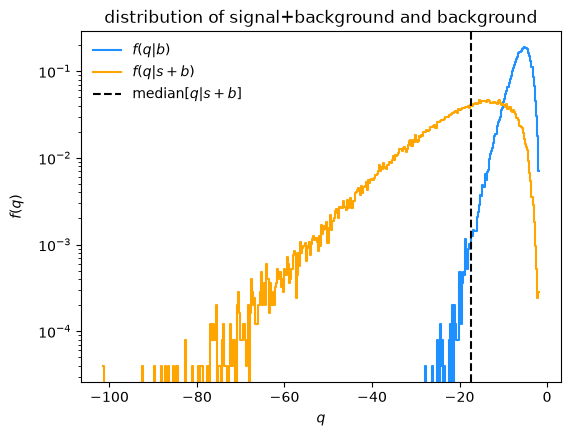

In [48]:
ybPlot = np.array([qbHist, qbHist]).T.flatten()

# Plot histograms of q
binLo, binHi = bin_edges[:-1], bin_edges[1:]
xPlot = np.array([binLo, binHi]).T.flatten()
ybPlot = np.array([qbHist, qbHist]).T.flatten()
ysbPlot = np.array([qsbHist, qsbHist]).T.flatten()
# xPlot = np.array(binLo)
# ybPlot = np.array(qbHist)
# ysbPlot = np.array(qsbHist)
fig, ax = plt.subplots(1,1)
plt.yscale("log")
plt.gcf().subplots_adjust(bottom=0.15)
plt.gcf().subplots_adjust(left=0.15)
plt.title("distribution of signal+background and background")
plt.xlabel(r'$q$', labelpad=5)
plt.ylabel(r'$f(q)$', labelpad=10)
plt.plot(xPlot, ybPlot, label=r'$f(q|b)$', color='dodgerblue')
plt.plot(xPlot, ysbPlot, label=r'$f(q|s+b)$', color='orange')
ax.axvline(med_q_sb, color="black", linestyle="dashed", label = r'median$[q|s+b]$')
ax.legend(loc='upper left', frameon=False)
plt.show()

In [46]:
# Add code to calculate the p-value of the b-only hypothesis
# for the median q from data generated according to s+b.
# Find the corresponding significance Z.

p_value=np.mean(qb>=med_q_sb)
print("p-value of the b-only hypothesis for the median q from s+b data: ",p_value)
Z = stats.norm.isf(p_value)
print("Corresponding significance Z: ",Z)

p-value of the b-only hypothesis for the median q from s+b data:  0.99809
Corresponding significance Z:  -2.8926555293459435


One thing we have to make sure that the background is not entirely less than median. If it is less then our significance goes to infinity indicating our false positive rates are at maximum which is very unlikely.